In [1]:
# Load necessary library 
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 
import scipy.stats as stats

In [2]:
# Load dataset 
df = pd.read_excel("C:\\Users\\shivraj\\OneDrive\\Desktop\\updated Hospital data 1.xlsx", header=0 )

In [3]:
# Showing top 5 rows
df.head()

,Age_group,Gender,Household_size,Family_type,Residence_area,Occupation_of_main_earner,Highest_education_in_household,Ration_Card_type,Type_of_hospital,Type_of_patient,...,Ease_of_access_numeric,Trust_level_numeric,PCI,Health_Burden_Ratio,Financial_Stress_Index,PCI_norm,Health_norm,Stress_norm,Poverty_Score,Poverty_Status
0,60 and above,Female,5,0,Rural,Farming,Postgraduate,Orange,Private hospital,Outpatient,...,2,3,3450.100000,0.10,-2,0.904108,0.073394,0.2,0.514072,1
1,18–29,Male,4,0,Rural,Farming,Graduate,Orange,Private hospital,Outpatient,...,3,4,2875.000000,0.06,-3,0.924659,0.036697,0.1,0.493339,0
2,45-59,Female,3,0,Rural,Farming,Graduate,Orange,Private hospital,Outpatient,...,3,3,5750.166667,0.08,-2,0.821915,0.055046,0.2,0.467471,0
3,45-59,Female,10,1,Rural,Farming,Graduate,Orange,Private hospital,Outpatient,...,3,2,3450.000000,0.08,-3,0.904111,0.055046,0.1,0.488569,0
4,18–29,Male,5,0,Rural,Farming,Postgraduate,Orange,Government hospital,Inpatient,...,2,3,3450.100000,0.04,-2,0.904108,0.018349,0.2,0.497558,0


In [4]:
# Checking null value 
df.isnull().sum()

Age_group                          0
Gender                             0
Household_size                     0
Family_type                        0
Residence_area                     0
Occupation_of_main_earner          0
Highest_education_in_household     0
Ration_Card_type                   0
Type_of_hospital                   0
Type_of_patient                    0
Type_of_illness                    0
Visits_per_month_numeric           0
Hospital_visit_cost_numeric        0
Consultation_fee_numeric           0
Medicine_cost_numeric              0
Diagnostics_cost_numeric           0
Travel_cost_numeric                0
Total_Health_Exp                   0
Monthly_income_numeric             0
Lost_income_numeric                0
Borrowed_money_numeric             0
Financial_hardship_numeric         0
Financial_stability_numeric        0
Insurance_enrolled_numeric         0
Insurance_used_numeric             0
Financial_support_level_numeric    0
Ease_of_access_numeric             0
T

C:\Users\shivraj\AppData\Local\Temp\ipykernel_20820\1367573249.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([df[col].dropna() for col in cols], labels=cols)


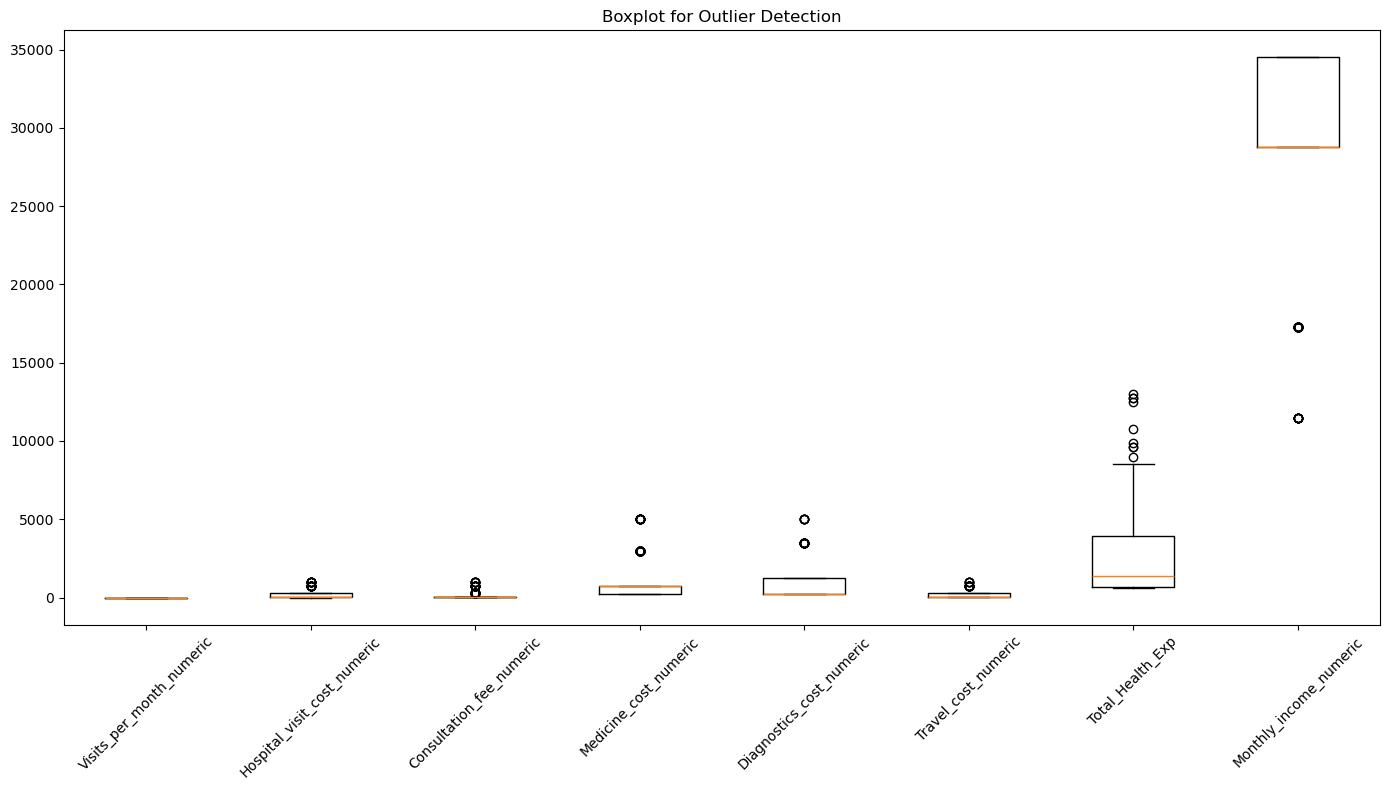

In [5]:
# Checking outliers present in data 

# Select variables
cols = [
    'Visits_per_month_numeric',
    'Hospital_visit_cost_numeric',
    'Consultation_fee_numeric',
    'Medicine_cost_numeric',
    'Diagnostics_cost_numeric',
    'Travel_cost_numeric',
    'Total_Health_Exp',
    'Monthly_income_numeric'
]

# Create figure
plt.figure(figsize=(14, 8))

# Boxplot
plt.boxplot([df[col].dropna() for col in cols], labels=cols)

# Rotate labels for clarity
plt.xticks(rotation=45)

# Title
plt.title('Boxplot for Outlier Detection')

# Layout adjust
plt.tight_layout()

# Show plot
plt.show()

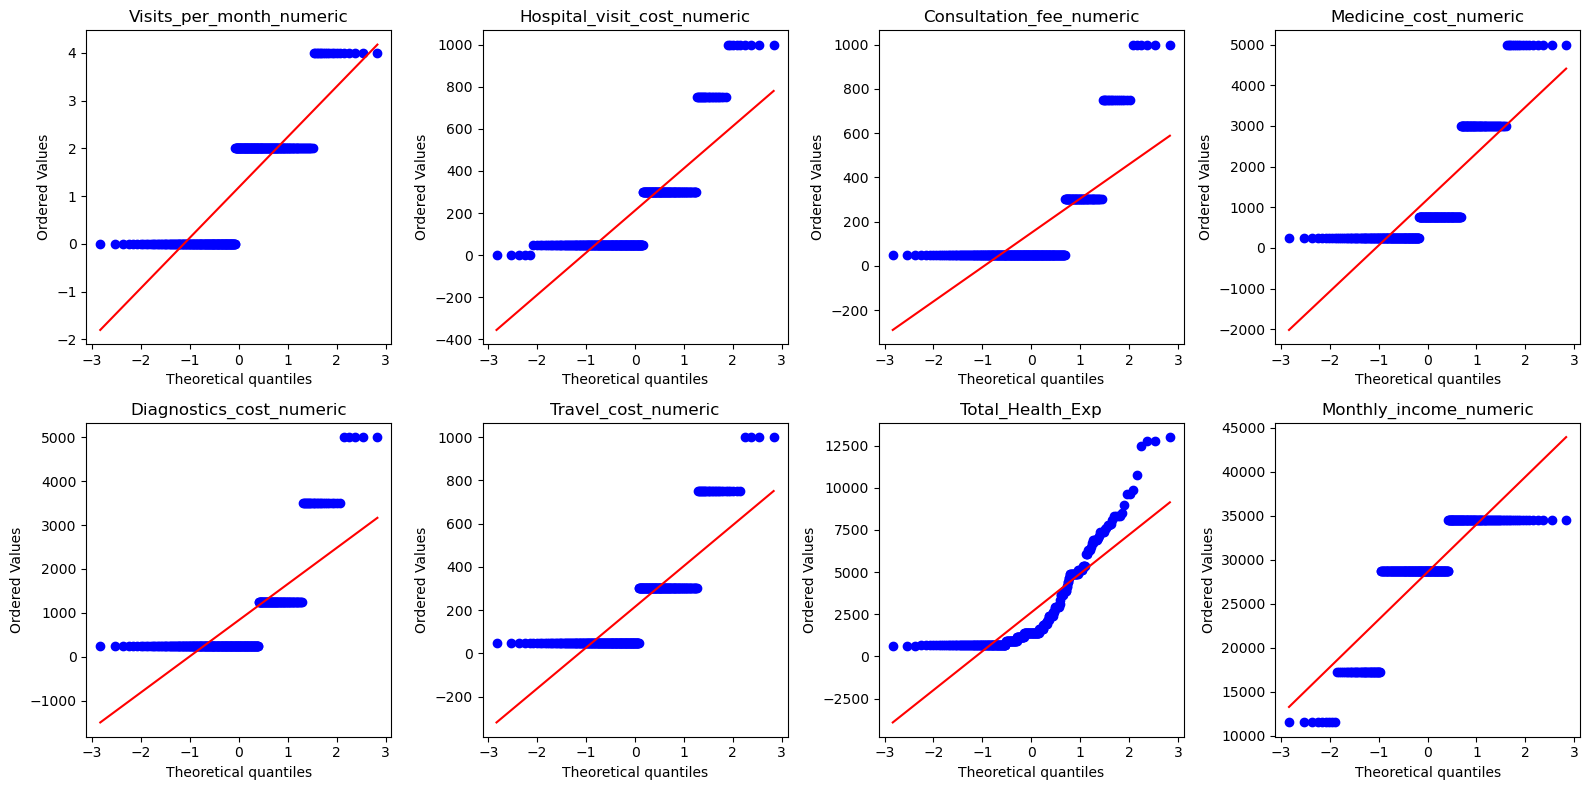

In [6]:
# Checking data is normal or not 

cols = [
    'Visits_per_month_numeric',
    'Hospital_visit_cost_numeric',
    'Consultation_fee_numeric',
    'Medicine_cost_numeric',
    'Diagnostics_cost_numeric',
    'Travel_cost_numeric',
    'Total_Health_Exp',
    'Monthly_income_numeric'
]

# Create subplots (2 rows × 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes = axes.flatten()

for i, col in enumerate(cols):
    stats.probplot(df[col].dropna(), dist="norm", plot=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [7]:
# Robust method for outliers 

from sklearn.preprocessing import RobustScaler

cols = [
    'Hospital_visit_cost_numeric',
    'Consultation_fee_numeric',
    'Medicine_cost_numeric',
    'Diagnostics_cost_numeric',
    'Travel_cost_numeric',
    'Total_Health_Exp',
    'Monthly_income_numeric'
]

# Initialize scaler
scaler = RobustScaler()

# Fit and transform
df[cols] = scaler.fit_transform(df[cols])

# Check result
print(df[cols].head())

   Hospital_visit_cost_numeric  Consultation_fee_numeric  \
0                          1.0                     250.5   
1                          0.0                       0.0   
2                          0.0                       0.0   
3                          0.0                     250.5   
4                          0.0                       0.0   

   Medicine_cost_numeric  Diagnostics_cost_numeric  Travel_cost_numeric  \
0                    0.0                       0.0                  0.0   
1                   -1.0                       0.0                  0.0   
2                    0.0                       0.0                  1.0   
3                    0.0                       1.0                  1.0   
4                   -1.0                       0.0                  0.0   

   Total_Health_Exp  Monthly_income_numeric  
0          0.077041               -2.000174  
1         -0.230970               -3.000348  
2          0.000000               -2.000174  
3   

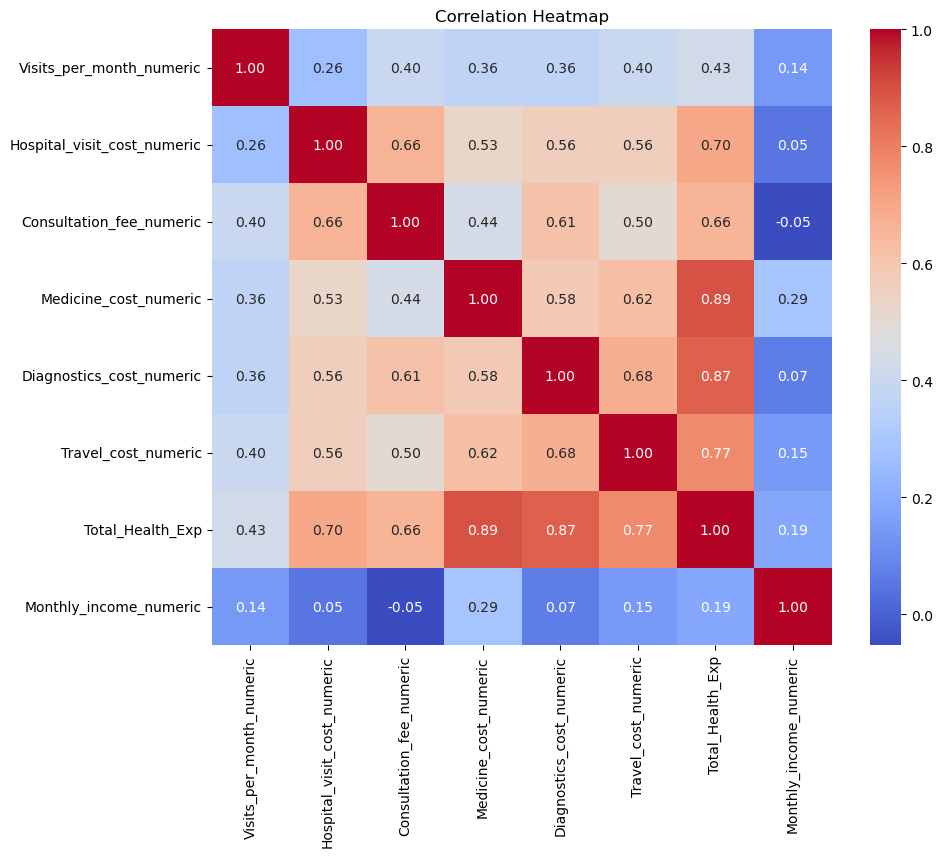

In [8]:
# Checking Correlation between variables 

cols = [
    'Visits_per_month_numeric',
    'Hospital_visit_cost_numeric',
    'Consultation_fee_numeric',
    'Medicine_cost_numeric',
    'Diagnostics_cost_numeric',
    'Travel_cost_numeric',
    'Total_Health_Exp',
    'Monthly_income_numeric'
]

# Compute correlation matrix
corr_matrix = data[cols].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

In [8]:
# step for feature selection 

X = df.drop(columns=['Poverty_Status'])   # target remove
y = df['Poverty_Status']

# indentify Columns Data type
num_cols = [
    'Visits_per_month_numeric','Hospital_visit_cost_numeric',
    'Consultation_fee_numeric','Medicine_cost_numeric',
    'Diagnostics_cost_numeric','Travel_cost_numeric',
    'Total_Health_Exp','Monthly_income_numeric',
    'Lost_income_numeric','Borrowed_money_numeric',
    'Financial_hardship_numeric','Financial_stability_numeric',
    'Insurance_enrolled_numeric','Insurance_used_numeric',
    'Financial_support_level_numeric','Ease_of_access_numeric',
    'Trust_level_numeric' 
]

cat_cols = [
    'Age_group','Gender','Family_type',
    'Residence_area','Occupation_of_main_earner',
    'Highest_education_in_household','Ration_Card_type',
    'Type_of_hospital','Type_of_patient','Type_of_illness'
]


# Applying Logistic regression + preprocessing 

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegressionCV

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first'), cat_cols)
])

# Pipeline with Lasso
model = Pipeline([
    ('preprocess', preprocessor),
    ('logit', LogisticRegressionCV(
        penalty='l1',
        solver='saga',
        cv=5,
        max_iter=5000))
])

# Fit model
model.fit(X, y)

C:\Users\shivraj\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
C:\Users\shivraj\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
C:\Users\shivraj\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new be

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('logit', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [9]:
# Important Feature 

# Get feature names after encoding
feature_names = (
    num_cols + 
    list(model.named_steps['preprocess']
         .named_transformers_['cat']
         .get_feature_names_out(cat_cols))
)

# Coefficients
coef = model.named_steps['logit'].coef_[0]

# Convert to series
importance = pd.Series(coef, index=feature_names)

# Selected features
selected_features = importance[importance != 0]

print(selected_features.sort_values(ascending=False))

Family_type_1                  1.648823
Financial_hardship_numeric     1.251629
Total_Health_Exp               1.193607
Lost_income_numeric            0.274350
Travel_cost_numeric            0.268683
Borrowed_money_numeric         0.028101
Visits_per_month_numeric       0.027248
Trust_level_numeric           -0.223230
Financial_stability_numeric   -0.601229
Monthly_income_numeric        -1.371095
dtype: float64


In [10]:
# Random Forest algorithm for feature selection 

from sklearn.ensemble import RandomForestClassifier

rf = Pipeline([
    ('preprocess', preprocessor),
    ('rf', RandomForestClassifier())
])

rf.fit(X, y)

importances = rf.named_steps['rf'].feature_importances_

In [12]:
# Get feature names after preprocessing
feature_names = (
    num_cols +
    list(rf.named_steps['preprocess']
         .named_transformers_['cat']
         .get_feature_names_out(cat_cols))
)

# Get importance values
importances = rf.named_steps['rf'].feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(
    by='Importance', ascending=False
)

# Show top features
print(feature_importance_df.head(20))

                              Feature  Importance
10         Financial_hardship_numeric    0.170267
11        Financial_stability_numeric    0.118359
6                    Total_Health_Exp    0.072758
16                Trust_level_numeric    0.061596
7              Monthly_income_numeric    0.060481
15             Ease_of_access_numeric    0.056239
9              Borrowed_money_numeric    0.047136
8                 Lost_income_numeric    0.037670
1         Hospital_visit_cost_numeric    0.034790
5                 Travel_cost_numeric    0.031419
2            Consultation_fee_numeric    0.029767
3               Medicine_cost_numeric    0.025194
4            Diagnostics_cost_numeric    0.024575
22                      Family_type_1    0.022641
14    Financial_support_level_numeric    0.018401
0            Visits_per_month_numeric    0.016690
24  Occupation_of_main_earner_Farming    0.014169
34            Ration_Card_type_Yellow    0.012898
21                        Gender_Male    0.011584


# Applying ML Models 

In [11]:
# prepare data
import pandas as pd

features = [
    'Financial_hardship_numeric',
    'Total_Health_Exp',
    'Lost_income_numeric',
    'Travel_cost_numeric',
    'Visits_per_month_numeric',
    'Borrowed_money_numeric',
    'Trust_level_numeric',
    'Financial_stability_numeric',
    'Monthly_income_numeric',
    'Family_type'
]

X = df[features]
y = df['Poverty_Status']

In [12]:
# Data split into training and testing 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
# convert categorical variable in numeric using one hot encoding 
import pandas as pd

X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Align columns (important!)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [14]:
# Scaling variable 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

In [16]:
# Train models
from sklearn.metrics import accuracy_score

results = {}

# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)
results['Logistic'] = accuracy_score(y_test, y_pred)

# Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
y_pred = dt_model.predict(X_test)
results['Decision Tree'] = accuracy_score(y_test, y_pred)

# Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
results['Random Forest'] = accuracy_score(y_test, y_pred)

# SVM
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)
y_pred = svm_model.predict(X_test_scaled)
results['SVM'] = accuracy_score(y_test, y_pred)

# KNN
knn_model = KNeighborsClassifier()
knn_model.fit(X_train_scaled, y_train)
y_pred = knn_model.predict(X_test_scaled)
results['KNN'] = accuracy_score(y_test, y_pred)

# Print results
print(results)

{'Logistic': 0.9666666666666667, 'Decision Tree': 0.8666666666666667, 'Random Forest': 0.9833333333333333, 'SVM': 0.9666666666666667, 'KNN': 0.9833333333333333}


           Model  Accuracy
2  Random Forest  0.983333
4            KNN  0.983333
0       Logistic  0.966667
3            SVM  0.966667
1  Decision Tree  0.866667


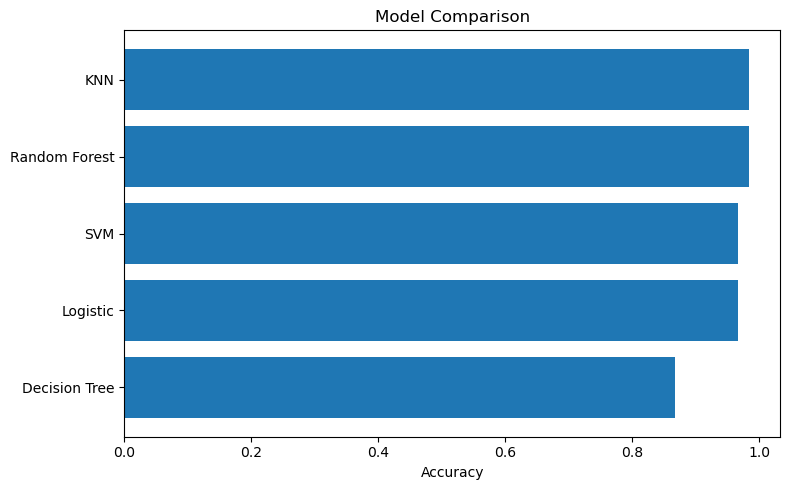

In [17]:
# Compare accuracy 
results_df = pd.DataFrame(list(results.items()), 
                          columns=['Model', 'Accuracy'])

print(results_df.sort_values(by='Accuracy', ascending=False))

# Visualization (bar graph)

import matplotlib.pyplot as plt

results_df = results_df.sort_values(by='Accuracy')

plt.figure(figsize=(8,5))
plt.barh(results_df['Model'], results_df['Accuracy'])

plt.xlabel("Accuracy")
plt.title("Model Comparison")

plt.tight_layout()
plt.show()

In [19]:
# Checking overfitting 
from sklearn.metrics import accuracy_score

models = {
    'Logistic': log_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'SVM': svm_model,
    'KNN': knn_model
}

for name, model in models.items():
    
    # Train accuracy
    if name in ['Logistic', 'SVM', 'KNN']:
        train_pred = model.predict(X_train_scaled)
        test_pred = model.predict(X_test_scaled)
    else:
        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    print(f"{name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    print("-"*30)

Logistic
Train Accuracy: 0.9375
Test Accuracy: 0.9667
------------------------------
Decision Tree
Train Accuracy: 1.0000
Test Accuracy: 0.8667
------------------------------
Random Forest
Train Accuracy: 1.0000
Test Accuracy: 0.9833
------------------------------
SVM
Train Accuracy: 0.9417
Test Accuracy: 0.9667
------------------------------
KNN
Train Accuracy: 0.9292
Test Accuracy: 0.9833
------------------------------


In [20]:
# Cross validation 
from sklearn.model_selection import cross_val_score

for name, model in models.items():
    
    if name in ['Logistic', 'SVM', 'KNN']:
        scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    else:
        scores = cross_val_score(model, X_train, y_train, cv=5)
    
    print(f"{name} CV Accuracy: {scores.mean():.4f}")

Logistic CV Accuracy: 0.9167
Decision Tree CV Accuracy: 0.8542
Random Forest CV Accuracy: 0.8833
SVM CV Accuracy: 0.9125
KNN CV Accuracy: 0.8958


# Ensemble model 

In [21]:
# Hybrid model (voting classifier )

from sklearn.ensemble import VotingClassifier

# Define models
model1 = LogisticRegression(max_iter=1000)
model2 = SVC(probability=True)   # IMPORTANT: probability=True
model3 = RandomForestClassifier()

# Voting model
voting_model = VotingClassifier(
    estimators=[
        ('lr', model1),
        ('svm', model2),
        ('rf', model3)
    ],
    voting='soft'   # use probability
)

# Fit model
voting_model.fit(X_train_scaled, y_train)

# Predict
y_pred = voting_model.predict(X_test_scaled)

# Accuracy
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test, y_pred)

print("Voting Classifier Accuracy:", acc)

Voting Classifier Accuracy: 0.9666666666666667


In [22]:
# Check model is overfit or not 

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

# Train prediction
train_pred = voting_model.predict(X_train_scaled)

# Test prediction
test_pred = voting_model.predict(X_test_scaled)

# Accuracy
train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print("Train Accuracy:", round(train_acc, 4))
print("Test Accuracy:", round(test_acc, 4))

# Overfitting check
if train_acc - test_acc > 0.05:
    print("Overfitting detected")
else:
    print("No overfitting")



Train Accuracy: 0.9625
Test Accuracy: 0.9667
No overfitting


# Model Deployment 

In [23]:
# Saving model 
import joblib

joblib.dump(voting_model, 'poverty_model.pkl')
joblib.dump(scaler, 'scaler.pkl')   # save scaler also

['scaler.pkl']

In [25]:
#Create Simple App using Streamlit

!pip install streamlit